In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
def create_heatmap(sr):
    hm_df = pd.DataFrame(sr).astype(float)
    hm_df.index = hm_df.index.astype(float)
    hm_df.columns = hm_df.columns.astype(float)

    plt.figure(figsize=(10, 6))
    sns.heatmap(hm_df, annot=True, fmt=".2f", cmap="coolwarm")
    plt.xlabel("Mean Window")
    plt.ylabel("Quantile")
    plt.title("Sharpe Heatmap")
    plt.show()

In [285]:
start_date = "2015-01-01"
end_date = "2023-12-31"
sector_universe = [
    "XLC",  # Communication Services
    "XLY",  # Consumer Discretionary
    "XLP",  # Consumer Staples
    "XLE",  # Energy
    "XLF",  # Financials
    "XLV",  # Health Care
    "XLI",  # Industrials
    "XLK",  # Information Technology
    "XLB",  # Materials
    "XLRE",  # Real Estate
    "XLU",  # Utilities
]
universe = [
    "XLC",  # Communication Services
    "XLY",  # Consumer Discretionary
    "XLP",  # Consumer Staples
    "XLE",  # Energy
    "XLF",  # Financials
    "XLV",  # Health Care
    "XLI",  # Industrials
    "XLK",  # Information Technology
    "XLB",  # Materials
    "XLRE",  # Real Estate
    "XLU",  # Utilities
    "GLD",
    "DBA",
    "URA",
    "TLT",
    "EDV",
    "IEF",
    "DBMF",
    "KMLM",
    "BTAL",
    "RPAR",
    "VIXY",
    "TAIL",
    "QUAL",
    "USMV",
    "AVUV",
    "DFSV",
    "EWJ",
    "EWW",
    "INDA",
    "FM",
]

In [333]:
data = yf.download(sector_universe, start=start_date, end=end_date)
close_df = data["Close"].dropna(axis=1)
volume_df = data["Volume"].dropna(axis=1)
returns_df = close_df.pct_change().fillna(0)
log_returns_df = np.log(close_df / close_df.shift(1))

[*********************100%***********************]  11 of 11 completed


<Axes: xlabel='Date'>

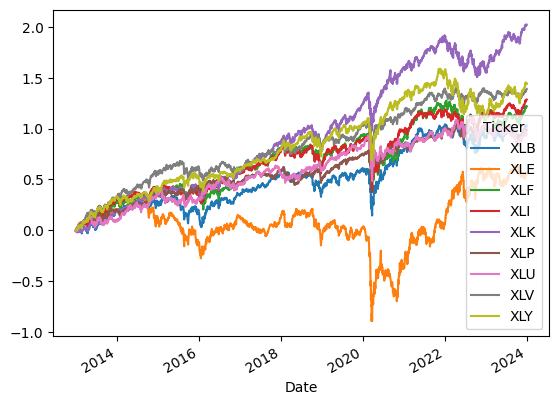

In [334]:
log_returns_df.cumsum().plot()

<Axes: xlabel='Date'>

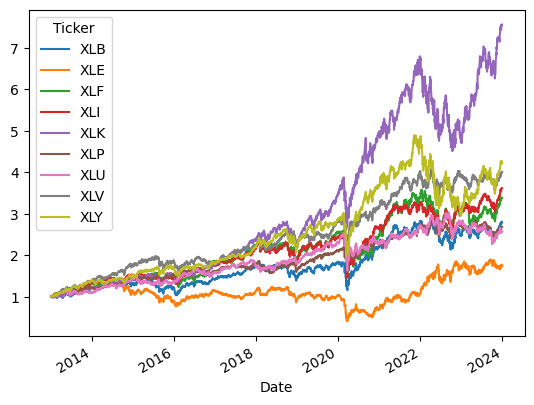

In [332]:
(1 + close_df.pct_change()).cumprod().plot()

In [287]:
spy_data = yf.download("SPY", start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [288]:
spy_close_df = spy_data["Close"].dropna(axis=1)
spy_ret_df = spy_close_df.pct_change()
spy_log_ret_df = np.log(spy_close_df / spy_close_df.shift(1)).dropna()

0.8240527221229417


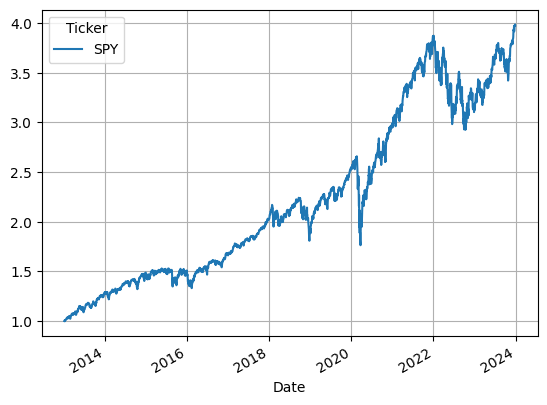

Max Drawdown: Ticker
SPY   -0.337173
dtype: float64


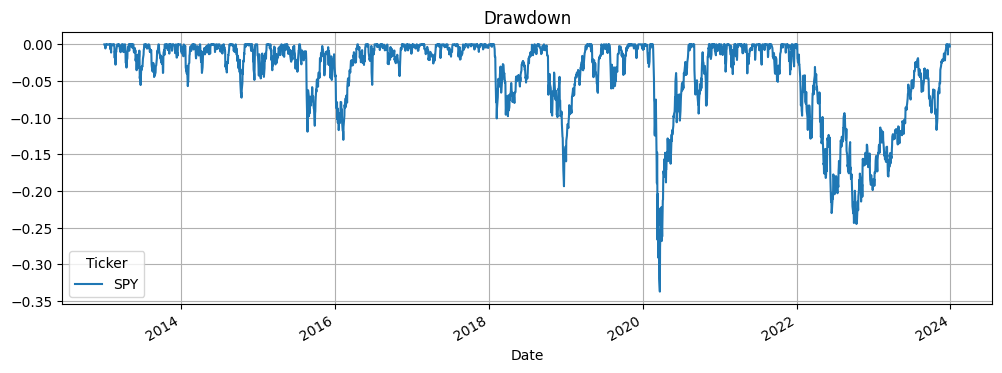

In [355]:
spy_ret = spy_ret_df.sum(axis=1)
sharpe = spy_ret.mean() / spy_ret.std() * np.sqrt(252)
print(sharpe)

(1 + spy_close_df.pct_change()).cumprod().plot(grid=True)
plt.show()

cum_pnl = (1 + spy_close_df.pct_change()).cumprod()

running_max = cum_pnl.cummax()
drawdown = cum_pnl / running_max - 1
max_dd = drawdown.min()

print("Max Drawdown:", max_dd)

drawdown.plot(figsize=(12, 4), title="Drawdown", grid=True)

plt.show()

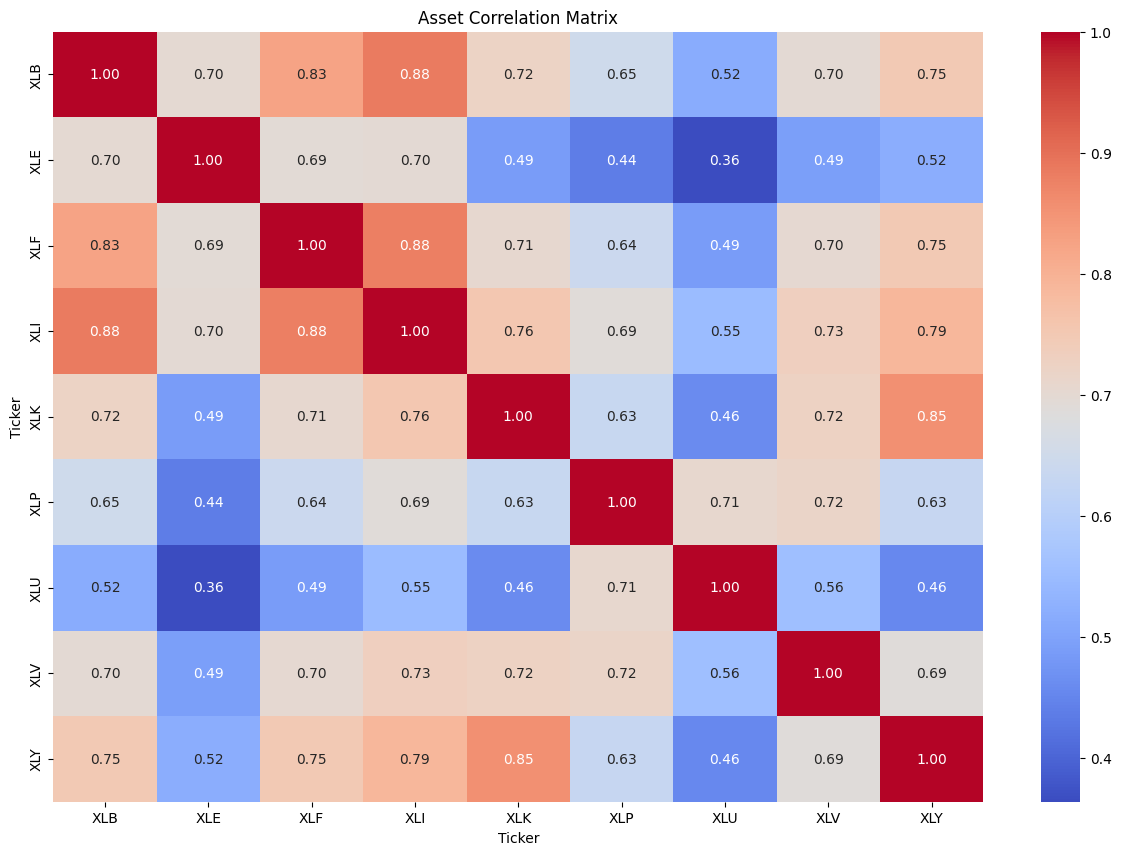

In [290]:
log_returns_df = np.log(close_df / close_df.shift(1)).dropna()
corr_matrix = log_returns_df.corr()

# Plotting the Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Asset Correlation Matrix")
plt.show()

In [163]:
window = 252  # 1 year rolling
range(window, len(log_returns_df), 21)

range(252, 2263, 21)

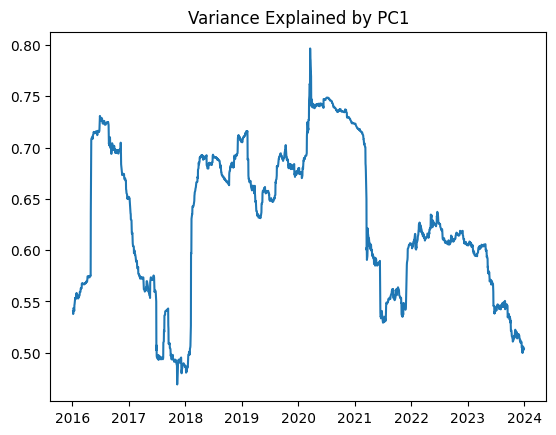

In [166]:
pc1_var = []
dates = []

for i in range(window, len(log_returns_df)):
    X = log_returns_df.iloc[i - window : i]
    pca = PCA()
    pca.fit(X)
    pc1_var.append(pca.explained_variance_ratio_[0])
    dates.append(log_returns_df.index[i])

plt.plot(dates, pc1_var)
plt.title("Variance Explained by PC1")
plt.show()

/Users/jplatta/repos/trade_lab/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/Users/jplatta/repos/trade_lab/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


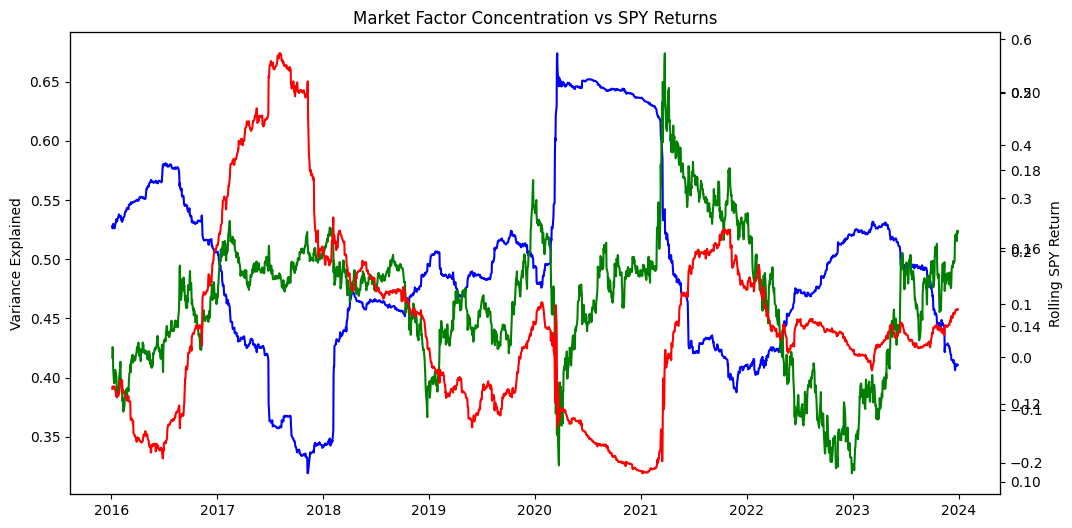

In [173]:
window = 252

pc1_var = []
pc2_var = []
spy_returns = []
dates = []

for i in range(window, len(log_returns_df)):
    X = log_returns_df.iloc[i - window : i]
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA()
    pca.fit(X_scaled)

    # variance explained by first PC
    pc1_var.append(pca.explained_variance_ratio_[0])
    pc2_var.append(pca.explained_variance_ratio_[1])

    # rolling SPY return
    spy_returns.append(spy_log_ret_df.iloc[i - window : i].sum())

    dates.append(log_returns_df.index[i])

df = pd.DataFrame({"PC1": pc1_var, "PC2": pc2_var, "SPY": spy_returns}, index=dates)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df.index, df["PC1"], color="blue", label="PC1")
ax1.set_ylabel("Variance Explained")

ax2 = ax1.twinx()
ax2.plot(df.index, df["SPY"], color="green")
ax2.set_ylabel("Rolling SPY Return")

ax3 = ax1.twinx()
ax3.plot(df.index, df["PC2"], color="red", label="PC2")

plt.title("Market Factor Concentration vs SPY Returns")
plt.show()

In [149]:
dist = np.sqrt((1 - corr_matrix) / 2)

BTAL 3
DBA 4
EDV 2
EWJ 1
EWW 1
FM 1
GLD 5
IEF 2
INDA 1
QUAL 1
TLT 2
URA 1
USMV 1
VIXY 3
XLB 1
XLE 1
XLF 1
XLI 1
XLK 1
XLP 1
XLU 1
XLV 1
XLY 1


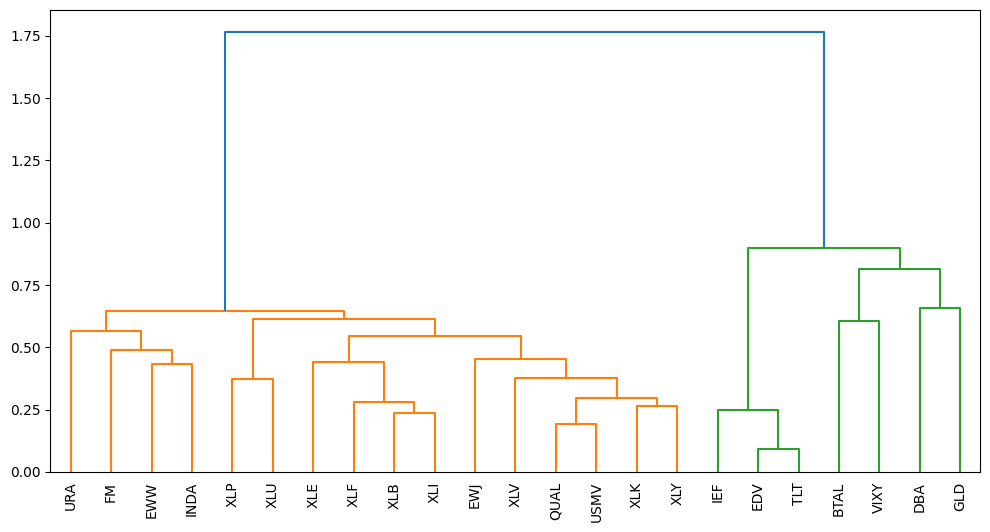

In [153]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

condensed = squareform(dist.values)

Z = linkage(condensed, method="ward")

clusters = fcluster(Z, t=5, criterion="maxclust")

for asset, cluster_id in zip(returns_df.columns, clusters):
    print(asset, cluster_id)

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=returns_df.columns.tolist())
plt.xticks(rotation=90)
plt.show()

In [156]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = returns_df.values
X = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X)

explained_var_ratio = pca.explained_variance_ratio_
loadings = pca.components_.T
loading_df = pd.DataFrame(
    loadings, index=returns_df.columns, columns=[f"PC{i + 1}" for i in range(loadings.shape[1])]
)

In [184]:
sum(explained_var_ratio[:6])

np.float64(0.8010855341931462)

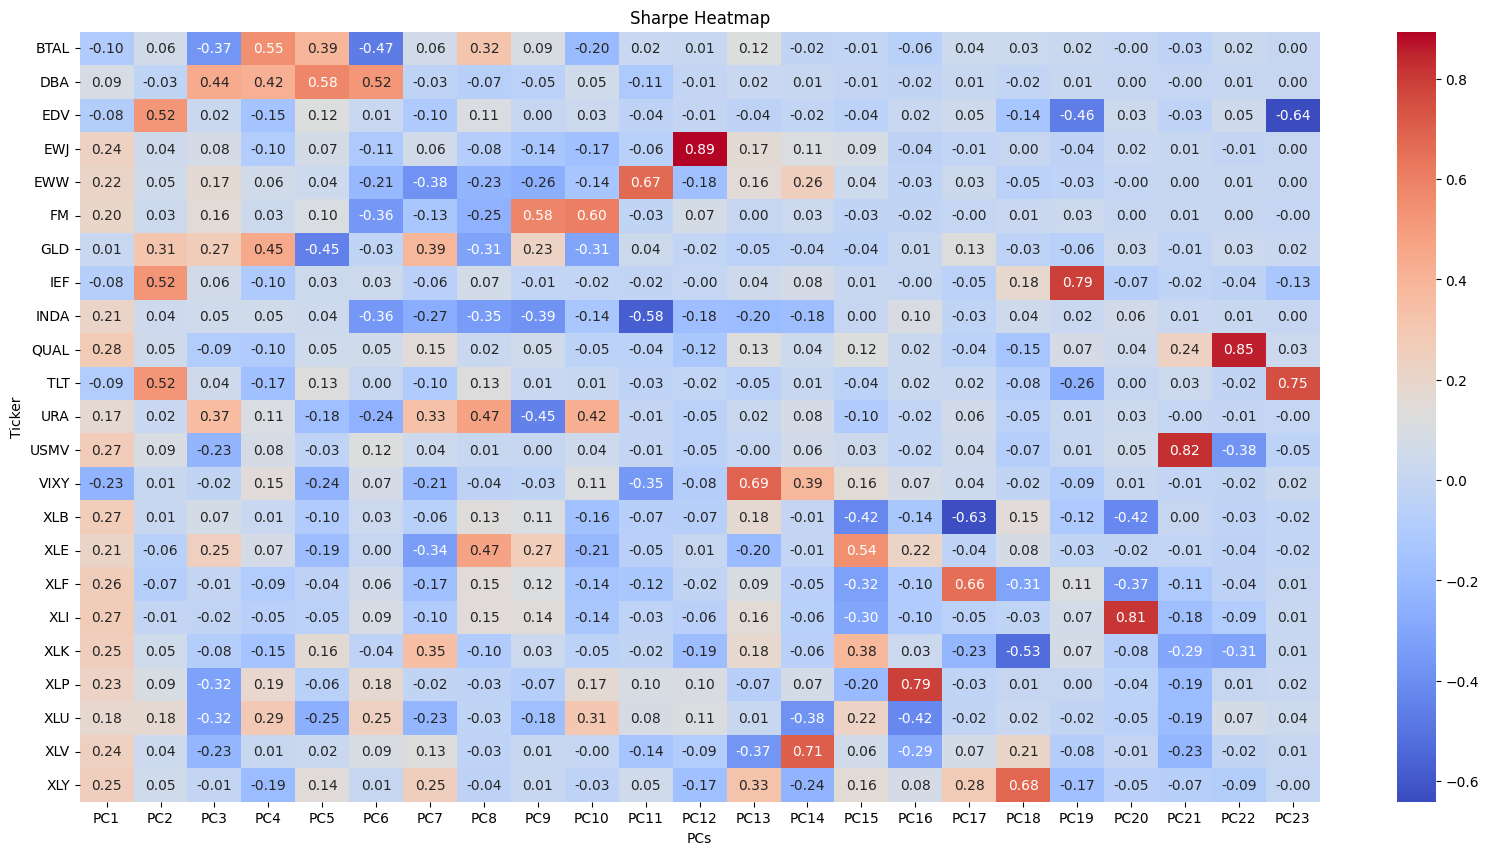

In [177]:
plt.figure(figsize=(20, 10))
sns.heatmap(loading_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.xlabel("PCs")
plt.ylabel("Ticker")
plt.title("Sharpe Heatmap")
plt.show()

## Test: PCA

In [202]:
mt_wind

120

In [205]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

n_components = 2
wind = 90

signal_df = pd.DataFrame(index=returns_df.index, columns=returns_df.columns, dtype=float)

for i in range(wind, len(returns_df)):
    # rolling window
    X = returns_df.iloc[i - wind : i]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # fit PCA
    pca = PCA(n_components=n_components)
    factors = pca.fit_transform(X_scaled)

    # reconstruct returns
    reconstructed = pca.inverse_transform(factors)

    # residuals
    residuals = X_scaled - reconstructed

    # latest residuals
    latest_resid = residuals[-1]

    # z-score signal
    zscore = (latest_resid - residuals.mean(axis=0)) / residuals.std(axis=0)

    signal_df.iloc[i] = zscore

In [211]:
residuals[-1]

array([-0.40118073,  0.16913068, -0.11766888,  0.53641564, -0.4530764 ,
        0.89545284, -0.59912765, -0.30771428,  0.34024685, -0.13254338,
       -0.17830944, -0.90206519,  0.17309306,  0.11293758, -0.42452741,
       -1.25789343,  0.20460064, -0.03289409, -0.03920164,  0.01578639,
        0.69138427,  0.31584051, -0.44560071])

In [214]:
residuals.shape

(90, 23)

In [219]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

adf_results = {}

for col in range(residuals.shape[1]):
    x = residuals[col]

    stat, pval, *_ = adfuller(x)
    adf_results[col] = pval

adf_pvals = pd.Series(adf_results).sort_values()

print(adf_pvals)

18    2.005682e-21
2     5.477092e-07
6     1.787410e-05
21    3.379214e-05
16    3.456930e-05
4     3.741557e-04
19    5.231225e-04
3     1.324629e-03
14    2.252585e-03
22    2.297866e-03
11    4.338758e-03
15    1.608351e-02
1     1.658616e-02
8     7.119203e-02
10    3.374686e-01
20    3.896491e-01
7     6.824311e-01
0     8.128723e-01
9     8.885138e-01
17    8.893560e-01
12    9.158916e-01
13    9.239459e-01
5     9.701928e-01
dtype: float64


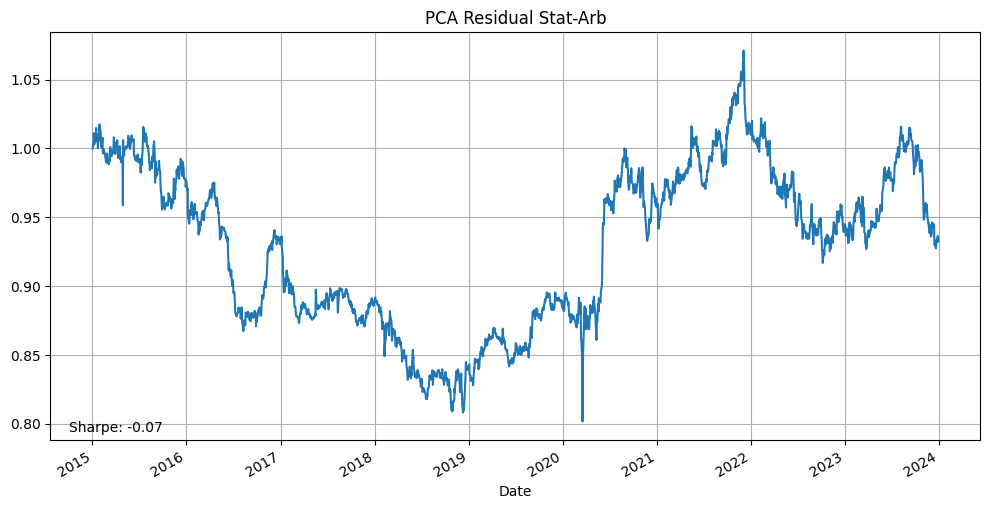

Sharpe: -0.06650036888395473
Max Drawdown: -0.21214877603617843


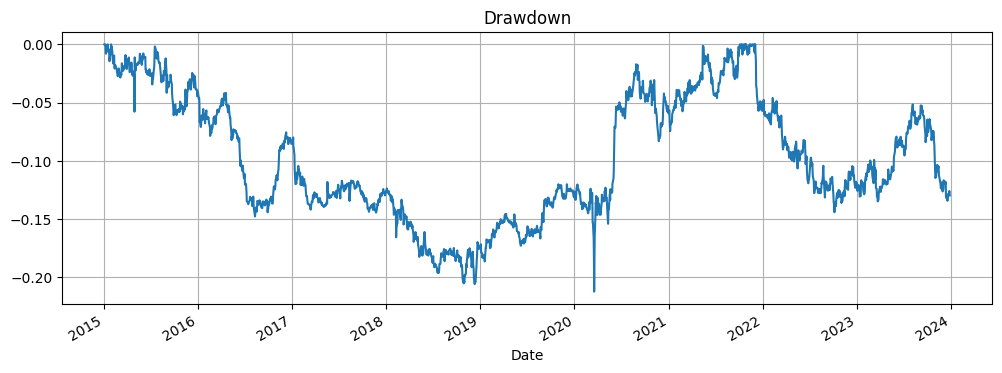

In [207]:
position_cnt = 4

signal_rank = signal_df.rank(
    axis=1,
    ascending=True,  # mean reversion
    na_option="bottom",
    method="first",
)

long = signal_rank <= position_cnt
short = signal_rank > (signal_rank.count(axis=1) - position_cnt).values[:, None]

# -----------------------------------
# Portfolio weights
# -----------------------------------
positions = long.astype(int) - short.astype(int)
positions = positions.div(positions.abs().sum(axis=1), axis=0)

# -----------------------------------
# Weekly rebalance
# -----------------------------------
rebalance_mask = np.arange(len(positions)) % 5 == 0

positions_weekly = positions.copy()
positions_weekly[~rebalance_mask] = np.nan
positions_weekly = positions_weekly.ffill()

# -----------------------------------
# Backtest
# -----------------------------------

pnl = positions_weekly.shift(1) * returns_df
port_ret = pnl.sum(axis=1)
sharpe = (port_ret.mean() / port_ret.std()) * np.sqrt(252)
cum_pnl = (1 + port_ret).cumprod()

# -----------------------------------
# Equity curve
# -----------------------------------

ax = cum_pnl.plot(figsize=(12, 6), grid=True, title="PCA Residual Stat-Arb")

plt.text(0.02, 0.02, f"Sharpe: {sharpe:.2f}", transform=ax.transAxes)

plt.show()

# -----------------------------------
# Drawdown
# -----------------------------------

running_max = cum_pnl.cummax()
drawdown = cum_pnl / running_max - 1
max_dd = drawdown.min()

print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)

drawdown.plot(figsize=(12, 4), title="Drawdown", grid=True)

plt.show()

## Test

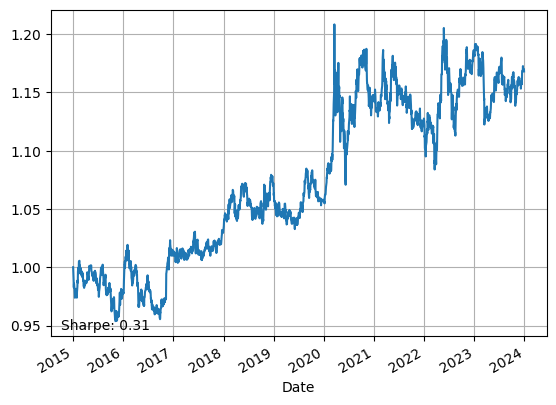

Max Drawdown: -0.1138547109150908


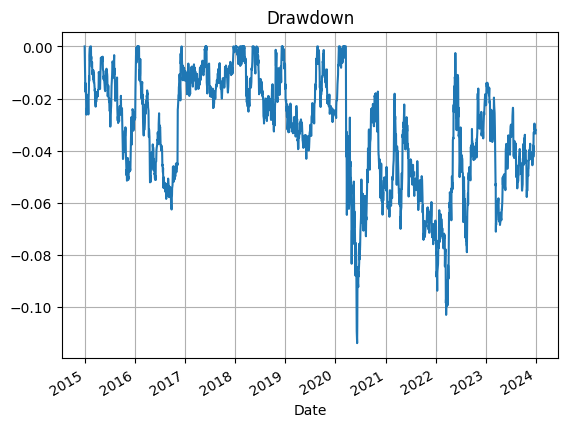

In [225]:
mt_wind = 120
position_cnt = 5

# signal_df = returns_df.shift(5).rolling(mt_wind).mean().shift(1)

base_signal = returns_df.shift(5).rolling(mt_wind).mean().shift(1)
realized_vol = returns_df.rolling(15).std().shift(1)
signal_df = base_signal / realized_vol

# signal_rank = signal_df.rank(axis=1, ascending=False,  na_option='bottom', method='first')
signal_rank = signal_df.rank(axis=1, ascending=False, na_option="bottom", method="first")

long = signal_rank <= position_cnt
short = signal_rank > (signal_rank.count(axis=1) - position_cnt).values[:, None]

positions = long.astype(int) - short.astype(int)
positions = positions.div(positions.abs().sum(axis=1), axis=0)

# NOTE: rebalance
rebalance_mask = np.arange(len(positions)) % 5 == 0  # 5 for weekly, 30 for monthly
positions_weekly = positions.copy()
positions_weekly[~rebalance_mask] = np.nan
positions_weekly = positions_weekly.ffill()

pnl = positions.shift(1) * returns_df
port_ret = pnl.sum(axis=1)
sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)
cum_pnl = (1 + port_ret).cumprod()

ax = cum_pnl.plot(grid=True)

plt.text(0.02, 0.02, f"Sharpe: {sharpe:.2f}", transform=ax.transAxes)
plt.show()

# cumulative equity curve
cum_ret = (1 + port_ret).cumprod()
# running peak
running_max = cum_ret.cummax()
# drawdown series
drawdown = cum_ret / running_max - 1
# max drawdown
max_dd = drawdown.min()

print("Max Drawdown:", max_dd)
drawdown.plot(title="Drawdown", grid=True)
plt.show()

In [230]:
spy_ret.corr(port_ret)

np.float64(-0.20427133983847107)

## Test: With SPY Regime Filter

In [349]:
common_index = returns_df.index.intersection(spy_ret_df.index)
returns_df = returns_df.loc[common_index]
spy_ret_df = spy_ret_df.loc[common_index]

X = sm.add_constant(spy_ret_df.squeeze())
residuals_df = pd.DataFrame(index=returns_df.index, columns=returns_df.columns)

for ticker in returns_df.columns:
    Y = returns_df[ticker]
    model = sm.OLS(Y, X, missing="drop").fit()
    residuals_df[ticker] = model.resid

In [350]:
residuals_df = residuals_df.dropna()

In [351]:
residuals_df.head()

Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,
2013-01-03,-0.004873,0.002436,0.001358,0.002815,-0.003849,-0.001109,0.001381,0.002975,0.004904
2013-01-04,0.007966,0.006551,0.007150,0.003068,-0.009436,-0.000052,0.002212,0.000730,-0.001015
2013-01-07,0.000815,-0.004498,0.000713,-0.001569,0.001731,-0.004995,-0.008111,0.005309,0.000472
2013-01-08,0.004585,0.000106,0.000278,-0.004781,-0.000474,-0.001010,-0.001335,0.002493,0.000210
2013-01-09,0.004004,-0.004175,-0.003879,0.007553,-0.001483,0.000586,-0.003658,0.008785,-0.001086


In [352]:
returns_df.head()

Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,
2013-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2013-01-03,-0.007276,-0.000274,-0.001185,0.000515,-0.006374,-0.002514,0.000000,0.001230,0.002477
2013-01-04,0.012304,0.011099,0.011869,0.007468,-0.004051,0.002801,0.005061,0.004420,0.003708
2013-01-07,-0.002069,-0.007724,-0.002346,-0.004345,-0.001356,-0.006702,-0.009793,0.003178,-0.002462
2013-01-08,0.001555,-0.003278,-0.002939,-0.007702,-0.003734,-0.002811,-0.003108,0.000244,-0.002880


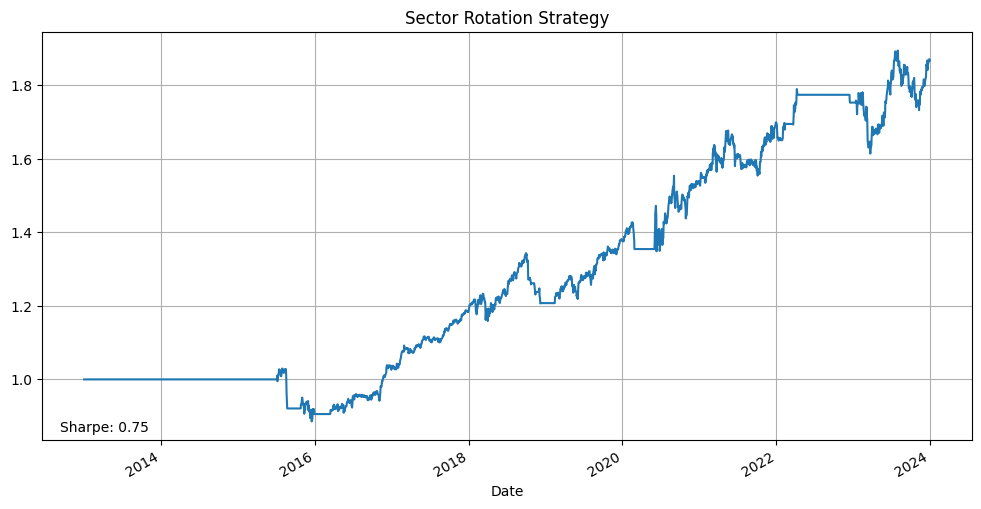

Sharpe: 0.7460178341782533
Max Drawdown: -0.13973503634540263


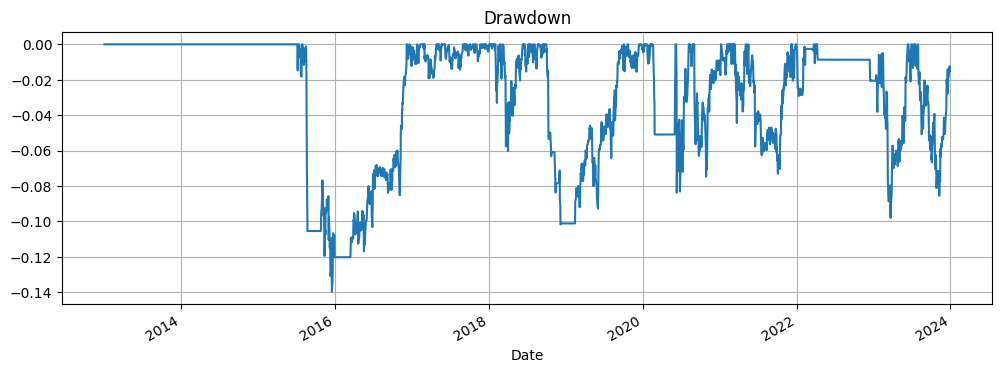

In [354]:
mt_wind = 120
position_cnt = 5

# -----------------------------------
# Momentum signal
# -----------------------------------

base_signal = residuals_df.shift(5).rolling(mt_wind).mean().shift(1)
realized_vol = residuals_df.rolling(15).std().shift(1)

signal_df = base_signal / realized_vol

# -----------------------------------
# Rank assets
# -----------------------------------
signal_rank = signal_df.rank(axis=1, ascending=False, na_option="bottom", method="first")

long = signal_rank <= position_cnt
short = signal_rank > (signal_rank.count(axis=1) - position_cnt).values[:, None]

# -----------------------------------
# Signal-weighted positions
# -----------------------------------

raw_positions = long.astype(int) - short.astype(int)
weighted_positions = raw_positions * signal_df
denom = weighted_positions.abs().sum(axis=1)
positions = weighted_positions.div(denom.replace(0, np.nan), axis=0).fillna(0)

# -----------------------------------
# SPY regime filter
# -----------------------------------

spy_200dma = spy_close_df.rolling(200).mean()
risk_on = spy_close_df > spy_200dma
positions = p.mul(risk_on.squeeze(), axis=0)

# -----------------------------------
# Weekly rebalance
# -----------------------------------

rebalance_mask = np.arange(len(positions)) % 5 == 0
positions_weekly = positions.copy()
positions_weekly[~rebalance_mask] = np.nan
positions_weekly = positions_weekly.ffill()

# -----------------------------------
# Backtest
# -----------------------------------
pnl = positions_weekly.shift(1) * returns_df

port_ret = pnl.sum(axis=1)

sharpe = (port_ret.mean() / port_ret.std()) * np.sqrt(252)

cum_pnl = (1 + port_ret).cumprod()

# -----------------------------------
# Equity curve
# -----------------------------------
ax = cum_pnl.plot(figsize=(12, 6), grid=True, title="Sector Rotation Strategy")

plt.text(0.02, 0.02, f"Sharpe: {sharpe:.2f}", transform=ax.transAxes)

plt.show()

# -----------------------------------
# Drawdown
# -----------------------------------
running_max = cum_pnl.cummax()
drawdown = cum_pnl / running_max - 1
max_dd = drawdown.min()

print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)

drawdown.plot(figsize=(12, 4), title="Drawdown", grid=True)

plt.show()

0.8240527221229417


<Axes: xlabel='Date'>

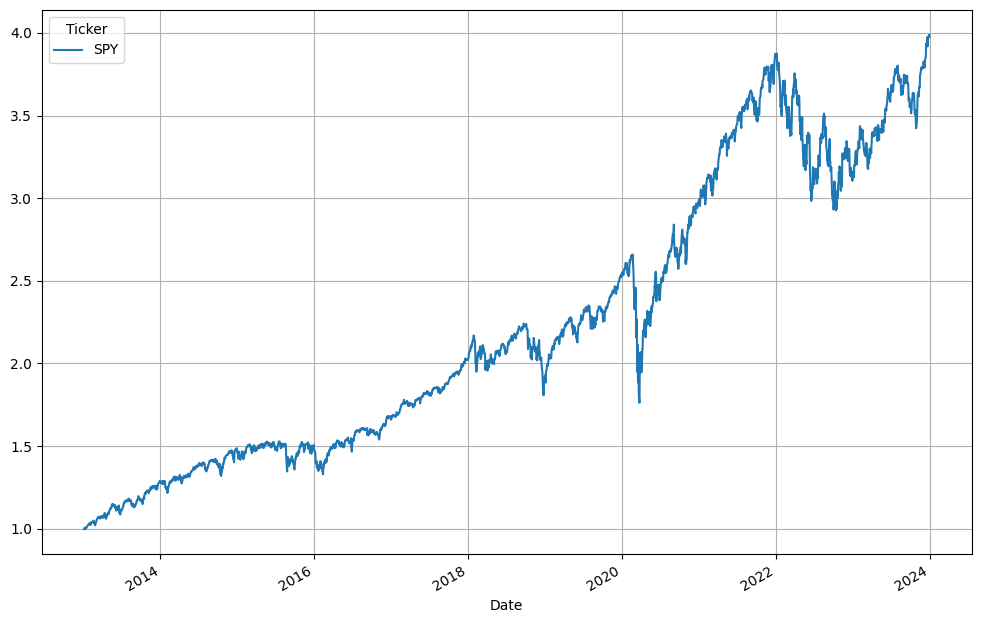

In [330]:
spy_ret = spy_ret_df.sum(axis=1)
sharpe = spy_ret.mean() / spy_ret.std() * np.sqrt(252)
print(sharpe)

(1 + spy_close_df.pct_change()).cumprod().plot(figsize=(12, 8), grid=True)

In [347]:
import statsmodels.api as sm

X = sm.add_constant(spy_ret_df.loc["2013-01-03":,])

model = sm.OLS(port_ret.loc["2013-01-03":,], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     890.8
Date:                Wed, 06 May 2026   Prob (F-statistic):          6.47e-170
Time:                        18:53:48   Log-Likelihood:                 11083.
No. Observations:                2767   AIC:                        -2.216e+04
Df Residuals:                    2765   BIC:                        -2.215e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001    8.4e-05      1.291      0.1

In [348]:
(port_ret.corr(spy_ret_df.squeeze()))

np.float64(0.4936224398339062)

In [270]:
(port_ret.corr(spy_ret_df.squeeze()))

np.float64(0.8414050186077701)

## Param Grid Search

In [29]:
sr = {}
mt_wind = 120
for qt in [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
    for vol_wind in [10, 20, 30, 40, 50, 60, 70, 80]:
        base_signal = returns_df.shift(5).rolling(mt_wind).mean().shift(1)

        realized_vol = returns_df.rolling(vol_wind).std()
        vol_thresh = realized_vol.rolling(40).quantile(qt)

        signal_df = base_signal.where(realized_vol.lt(vol_thresh, axis=0))

        signal_rank = signal_df.rank(axis=1, ascending=False)

        long = signal_rank <= position_cnt
        short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
        short = signal_rank.ge(short_cutoff.values[:, None])

        positions = long.astype(int) - short.astype(int)
        positions = positions.div(positions.abs().sum(axis=1), axis=0)

        # NOTE: rebalance monthly
        rebalance_mask = np.arange(len(positions)) % 30 == 0
        positions_mthly = positions.copy()
        positions_mthly[~rebalance_mask] = np.nan
        positions_mthly = positions_mthly.ffill()

        pnl = positions_mthly.shift(1) * returns_df
        port_ret = pnl.sum(axis=1)
        sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)

        qt_key = f"{qt}"
        if qt_key not in sr:
            sr[qt_key] = {}

        vol_wind_key = f"{vol_wind}"
        sr[qt_key][vol_wind_key] = sharpe

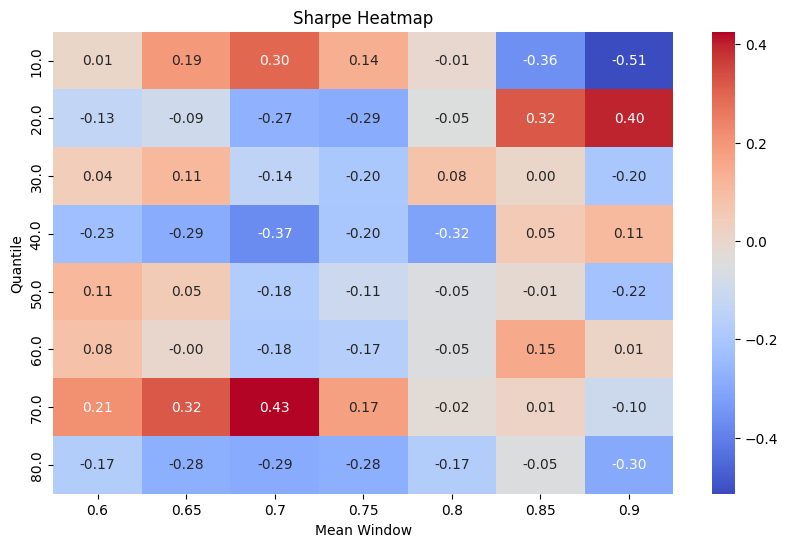

In [30]:
create_heatmap(sr)

In [53]:
sr = {}

for mt_wind in np.arange(60, 121, 10):
    for vol_wind in [10, 20, 30, 40, 50, 60, 70, 80]:
        base_signal = returns_df.shift(5).rolling(mt_wind).mean().shift(1)

        realized_vol = returns_df.rolling(vol_wind).std()
        vol_thresh = realized_vol.rolling(40).quantile(0.7)

        signal_df = base_signal.where(realized_vol.lt(vol_thresh, axis=0))

        signal_rank = signal_df.rank(axis=1, ascending=False, na_option="bottom")

        long = signal_rank <= position_cnt
        short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
        short = signal_rank.ge(short_cutoff.values[:, None])

        positions = long.astype(int) - short.astype(int)
        positions = positions.div(positions.abs().sum(axis=1), axis=0)

        # NOTE: rebalance weekly
        rebalance_mask = np.arange(len(positions)) % 5 == 0
        positions_mthly = positions.copy()
        positions_mthly[~rebalance_mask] = np.nan
        positions_mthly = positions_mthly.ffill()

        # NOTE: rebalance monthly
        # rebalance_mask = np.arange(len(positions)) % 30 == 0
        # positions_mthly = positions.copy()
        # positions_mthly[~rebalance_mask] = np.nan
        # positions_mthly = positions_mthly.ffill()

        pnl = positions_mthly.shift(1) * returns_df
        port_ret = pnl.sum(axis=1)
        sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)

        mt_wind_key = f"{mt_wind}"
        vol_wind_key = f"{vol_wind}"
        if mt_wind_key not in sr:
            sr[mt_wind_key] = {}

        sr[mt_wind_key][vol_wind_key] = sharpe

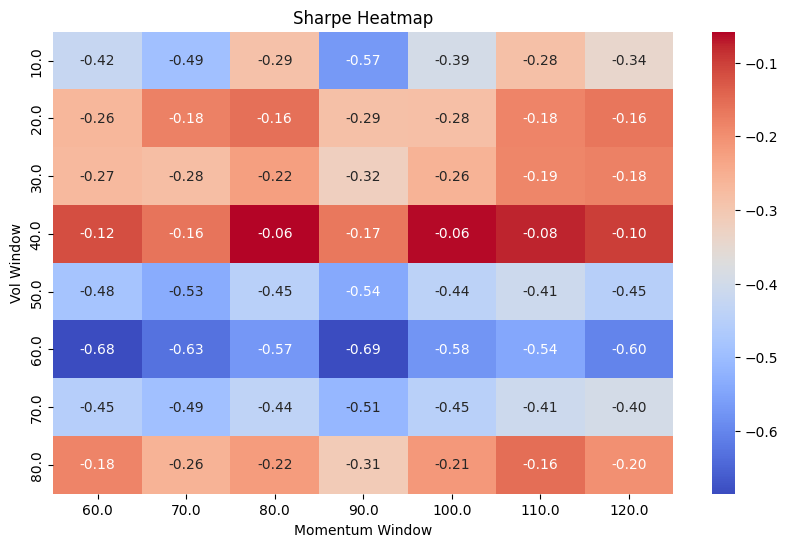

In [54]:
hm_df = pd.DataFrame(sr).astype(float)
hm_df.index = hm_df.index.astype(float)
hm_df.columns = hm_df.columns.astype(float)

plt.figure(figsize=(10, 6))
sns.heatmap(hm_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.xlabel("Momentum Window")
plt.ylabel("Vol Window")
plt.title("Sharpe Heatmap")
plt.show()